In [2]:
import re
import gc
import pandas as pd
import numpy as np

from pathlib import Path
from tqdm import tqdm

import spacy
import scispacy
import medspacy

notes = pd.read_csv(
    "../outputs/eda_base_dataset.csv"
)

print("Dataset shape:", notes.shape)


Dataset shape: (11061, 9)


In [3]:
import spacy
import medspacy

nlp = spacy.load("en_ner_bc5cdr_md")

nlp.add_pipe("sentencizer")

nlp.add_pipe("medspacy_context")

print(nlp.pipe_names)

['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer', 'parser', 'ner', 'sentencizer', 'medspacy_context']


In [4]:
def clean_note(text):

    if pd.isnull(text):
        return ""

    text = str(text)

    text = re.sub(
        r"\[\*\*.*?\*\*\]",
        " ",
        text
    )

    text = re.sub(r"[_\-]{2,}", " ", text)

    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"\r+", " ", text)
    text = re.sub(r"\t+", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.lower().strip()

print("\nCleaning notes...")

tqdm.pandas()

notes["clean_text"] = notes["TEXT"].progress_apply(clean_note)

print("Cleaning complete.")



Cleaning notes...


100%|██████████| 11061/11061 [00:06<00:00, 1709.03it/s]

Cleaning complete.


In [5]:
before = len(notes)

notes = notes[
    notes["clean_text"].str.len() > 50
].copy()

after = len(notes)

print(f"\nRemoved {before - after:,} short notes.")


Removed 0 short notes.


In [6]:
print("\n=== ENTITY LABEL DEBUG ===\n")

sample_text = notes.iloc[0]["clean_text"][:5000]
print(sample_text)

doc = nlp(sample_text)

print("Detected entities:\n")

for ent in doc.ents[:30]:
    print(ent.text, " --> ", ent.label_)

print("\nTotal entities:", len(doc.ents))



=== ENTITY LABEL DEBUG ===

name: , a unit no: admission date: discharge date: date of birth: sex: f service: addendum: the patient had to spend last night ( ) because of unable to transport in the evening and required dialysis during the day. this morning, she is doing well. she was found asleep. on examination, her abdomen was soft, nontender, and nondistended. she was afebrile. she was tolerating oral intake. she was complaining of nausea, but no vomiting. she was able to eat regular meals (a full meal). condition on discharge: same. discharge disposition: the patient to be discharged back to nursing facility today. , dictated by: medquist36 d: 07:46:00 t: 11:48:41 job#:
Detected entities:

nausea  -->  DISEASE

Total entities: 1


In [7]:
def extract_symptoms(doc):
    symptoms = []

    for ent in doc.ents:

        if ent.label_ != "DISEASE":
            continue

        text = ent.text.strip().lower()

        if len(text) < 3:
            continue
        try:
            context = ent._.context_attributes
            if context.get("is_negated", False):
                continue
            if context.get("is_uncertain", False):
                continue
        except:
            pass

        symptoms.append(text)

    return symptoms

def process_chunk(text_chunk):
    results = []

    pipe = nlp.pipe(
        text_chunk,
        batch_size=16,
        n_process=1
    )

    for doc in pipe:

        symptoms = extract_symptoms(doc)

        results.append(symptoms)

    return results

In [8]:
CHUNK_SIZE = 1000

all_symptoms = []

texts = notes["clean_text"]

print("\nRunning clinical NER...\n")

for start in tqdm(
    range(0, len(texts), CHUNK_SIZE)
):

    end = start + CHUNK_SIZE

    chunk = texts.iloc[start:end]

    chunk_results = process_chunk(chunk)

    all_symptoms.extend(chunk_results)

    del chunk_results
    gc.collect()

notes["symptoms"] = all_symptoms

print("\nNER extraction complete.")


Running clinical NER...



100%|██████████| 12/12 [25:42<00:00, 128.57s/it]


NER extraction complete.


In [9]:
notes["symptom_str"] = (
    notes["symptoms"]
    .apply(lambda x: " ".join(x))
)

before = len(notes)

notes = notes[
    notes["symptom_str"].str.len() > 0
].copy()

after = len(notes)

print(f"\nRemoved {before - after:,} empty notes.")

print("\nRemaining notes:", len(notes))


Removed 336 empty notes.

Remaining notes: 10725


In [10]:
notes["symptom_count"] = (
    notes["symptoms"]
    .apply(len)
)

print("\n=== Symptom Count Statistics ===\n")

print(
    notes["symptom_count"]
    .describe()
)


=== Symptom Count Statistics ===

count    10725.000000
mean        29.598788
std         20.319732
min          1.000000
25%         14.000000
50%         25.000000
75%         41.000000
max        207.000000
Name: symptom_count, dtype: float64


In [11]:
print("\n=== EXTRACTION QUALITY CHECK ===\n")
samples = notes.sample(
    n=min(5, len(notes)),
    random_state=42
)

for _, row in samples.iterrows():
    print("=" * 80)

    print("HADM_ID:", row["HADM_ID"])

    print("\nTOP SYMPTOMS:")

    print(row["symptoms"][:20])

    print("\nTEXT PREVIEW:\n")

    print(row["clean_text"][:800])

    print("\n")


=== EXTRACTION QUALITY CHECK ===

HADM_ID: 196510.0

TOP SYMPTOMS:
['left hemothorax', 'hemothorax', 'atrial fibrillation', 'atrial fibrillation', 'shortness of breath', 'left pleuritic pain', 'hemothorax', 'atrial fibrillation', 'bleeding', 'bleeding', 'bleeding', 'bleeding']

TEXT PREVIEW:

admission date: discharge date: date of birth: sex: m service: most responsible diagnosis: left hemothorax (delayed hemothorax after recent coronary artery bypass grafting surgery). other diagnoses: 1. recent coronary artery bypass grafting with use of the left internal mammary artery. 2. recent treatment for atrial fibrillation. 3. recent anticoagulation for atrial fibrillation. procedures: 1. - bedside insertion of chest tube. 2. - dr. - left thoracoscopy for hemothorax. history: this man recently underwent coronary artery bypass graft surgery by dr. . he had done well and went home. however, he returned on the evening of complaining of shortness of breath and left pleuritic pain. he was found 

In [12]:
from collections import Counter

all_terms = []

for sym_list in notes["symptoms"]:
    all_terms.extend(sym_list)

counter = Counter(all_terms)

top_symptoms = pd.DataFrame(
    counter.most_common(50),
    columns=["symptom", "count"]
)

print("\n=== TOP SYMPTOMS ===\n")
print(top_symptoms)


=== TOP SYMPTOMS ===

                     symptom  count
0                       pain  11970
1               hypertension   7106
2                  allergies   5637
3                 chest pain   4640
4                  pneumonia   4347
5        atrial fibrillation   4211
6        shortness of breath   3993
7                hypotension   3780
8                      fever   3678
9    coronary artery disease   3386
10                    anemia   3224
11                       htn   3101
12                    nausea   2984
13                    sepsis   2980
14                     edema   2891
15                  bleeding   2616
16      mitral regurgitation   2604
17      respiratory distress   2378
18            abdominal pain   2295
19                 infection   2249
20  congestive heart failure   2083
21                  fracture   1986
22                     cough   1962
23                  hematoma   1866
24                  diabetes   1851
25      hypercholesterolemia   1846
26   

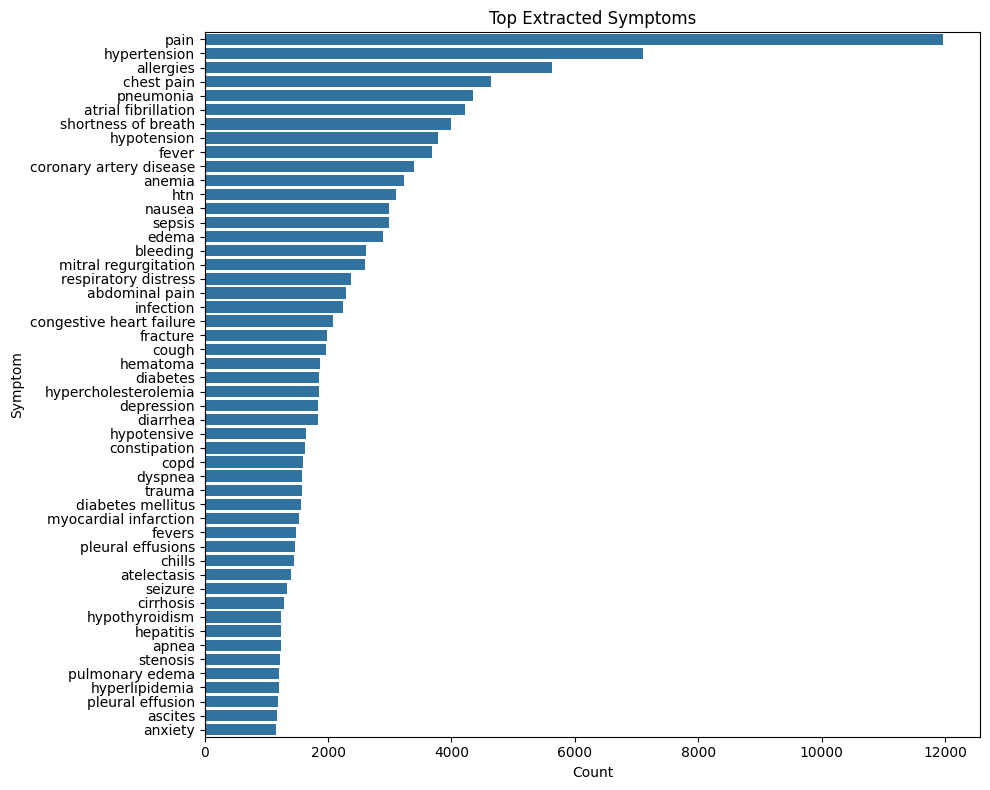

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_symptoms,
    y="symptom",
    x="count"
)

plt.title("Top Extracted Symptoms")

plt.xlabel("Count")

plt.ylabel("Symptom")

plt.tight_layout()

plt.savefig(
    "../outputs/top_symptoms.png",
    dpi=150
)

plt.show()

In [14]:
save_cols = [
    "SUBJECT_ID",
    "HADM_ID",
    "ADMISSION_TYPE",
    "DIAGNOSIS",
    "HOSPITAL_EXPIRE_FLAG",
    "clean_text",
    "symptoms",
    "symptom_str",
    "symptom_count"
]

from tqdm import tqdm

tqdm.pandas()

notes["clean_text"] = notes["TEXT"].astype(str)


docs = nlp.pipe(
    notes["clean_text"],
    batch_size=16,
    n_process=1
)

notes["symptoms"] = [
    extract_symptoms(doc)
    for doc in tqdm(docs, total=len(notes))
]

notes["symptom_str"] = notes["symptoms"].apply(
    lambda x: " ".join(x)
)
notes["symptom_count"] = notes["symptoms"].apply(len)
notes[save_cols].to_csv(
    "../features/preprocessed_notes.csv",
    index=False
)

print("\nSaved:")

100%|██████████| 10725/10725 [36:16<00:00,  4.93it/s] 



Saved:
